# 1. 데이터 불러오기 및 결측치 처리

In [59]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

def iqr_bounds(series):
    clean = series.dropna()
    q1, q3 = clean.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return lower, upper, int(((clean < lower) | (clean > upper)).sum())

df = pd.read_csv("prj_data.csv")

In [60]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   고객ID     500 non-null    str    
 1   나이       460 non-null    float64
 2   성별       485 non-null    str    
 3   거주지역     500 non-null    str    
 4   가입경로     480 non-null    str    
 5   멤버십등급    500 non-null    str    
 6   월평균구매금액  500 non-null    float64
 7   구매횟수     500 non-null    float64
 8   리뷰점수     475 non-null    float64
 9   쿠폰사용여부   500 non-null    str    
 10  메모       216 non-null    str    
 11  이탈여부     500 non-null    int64  
dtypes: float64(4), int64(1), str(7)
memory usage: 47.0 KB


In [61]:
df.isnull().sum()

고객ID         0
나이          40
성별          15
거주지역         0
가입경로        20
멤버십등급        0
월평균구매금액      0
구매횟수         0
리뷰점수        25
쿠폰사용여부       0
메모         284
이탈여부         0
dtype: int64

In [62]:
missing_ratio = df.isnull().mean() * 100
missing_ratio

고객ID        0.0
나이          8.0
성별          3.0
거주지역        0.0
가입경로        4.0
멤버십등급       0.0
월평균구매금액     0.0
구매횟수        0.0
리뷰점수        5.0
쿠폰사용여부      0.0
메모         56.8
이탈여부        0.0
dtype: float64

In [63]:
drop_cols = missing_ratio[missing_ratio > 50].index.tolist()
df = df.drop(columns=drop_cols)

numeric_cols = df.select_dtypes(include=np.number).columns.drop("이탈여부")
categorical_cols = df.select_dtypes(exclude=np.number).columns.drop("고객ID")

for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

for col in categorical_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].mode()[0])

In [64]:
df.isnull().sum()

고객ID       0
나이         0
성별         0
거주지역       0
가입경로       0
멤버십등급      0
월평균구매금액    0
구매횟수       0
리뷰점수       0
쿠폰사용여부     0
이탈여부       0
dtype: int64

# 2. 이상치 탐지 및 처리

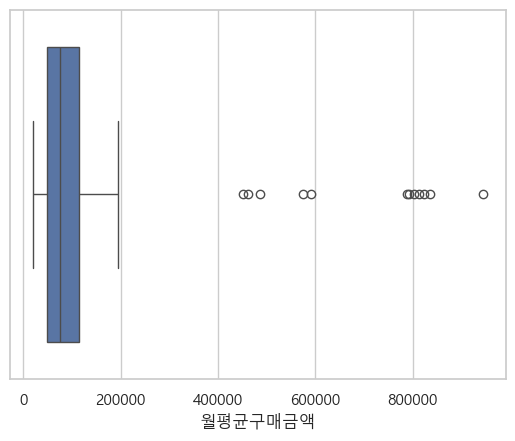

In [65]:
sns.boxplot(x=df["월평균구매금액"])
plt.show()

In [66]:
lower, upper, n_outlier = iqr_bounds(df["월평균구매금액"])
print(f"하한={lower:.2f}, 상한={upper:.2f}, 이상치 개수={n_outlier}")

하한=-50920.51, 상한=213834.06, 이상치 개수=12


In [ ]:
# 처리 방식: 제거 대신 경계값으로 대체(capping)
# 이유: 표본 수가 크지 않아 행을 삭제하면 다른 컬럼 정보까지 함께 손실되고,
#       상한을 초과하는 고액 구매 기록이 입력 오류가 아니라 실제 VIP성 고객일 가능성도 있어
#       완전히 버리기보다 분포 영향력만 줄이는 capping을 선택함
df["월평균구매금액"] = df["월평균구매금액"].clip(lower, upper)

# 3. 범주형 변수 인코딩

In [68]:
print("인코딩 전:", df.shape)
print(list(df.columns))

인코딩 전: (500, 11)
['고객ID', '나이', '성별', '거주지역', '가입경로', '멤버십등급', '월평균구매금액', '구매횟수', '리뷰점수', '쿠폰사용여부', '이탈여부']


- 멤버십등급: 브론즈 < 실버 < 골드 < VIP처럼 등급 간 서열이 있는 순서형 변수 -> 레이블 인코딩으로 순서 정보를 보존
- 성별, 거주지역, 가입경로, 쿠폰사용여부: 값들 간 서열이 없는 명목형 변수 -> 레이블 인코딩 시 모델이 존재하지 않는 크기·순서 관계를 학습할 위험이 있어 원-핫 인코딩 적용

In [69]:
order_map = {"브론즈": 0, "실버": 1, "골드": 2, "VIP": 3}
df["멤버십등급"] = df["멤버십등급"].map(order_map)

onehot_cols = ["성별", "거주지역", "가입경로", "쿠폰사용여부"]
df = pd.get_dummies(df, columns=onehot_cols)

In [70]:
print("인코딩 후:", df.shape)
print(list(df.columns))

인코딩 후: (500, 20)
['고객ID', '나이', '멤버십등급', '월평균구매금액', '구매횟수', '리뷰점수', '이탈여부', '성별_남', '성별_여', '거주지역_경기', '거주지역_기타', '거주지역_대구', '거주지역_부산', '거주지역_서울', '가입경로_광고', '가입경로_앱', '가입경로_웹', '가입경로_지인추천', '쿠폰사용여부_N', '쿠폰사용여부_Y']


# 4. 파생변수 생성 및 스케일링

In [71]:
df["회당평균구매금액"] = df["월평균구매금액"] / df["구매횟수"].replace(0, np.nan)
df["회당평균구매금액"] = df["회당평균구매금액"].fillna(df["회당평균구매금액"].median())

df.head()

,고객ID,나이,멤버십등급,월평균구매금액,구매횟수,리뷰점수,이탈여부,성별_남,성별_여,거주지역_경기,...,거주지역_대구,거주지역_부산,거주지역_서울,가입경로_광고,가입경로_앱,가입경로_웹,가입경로_지인추천,쿠폰사용여부_N,쿠폰사용여부_Y,회당평균구매금액
0,C0001,22.0,1,62705.653045,7.0,3.3,1,True,False,False,...,True,False,False,False,True,False,False,True,False,8957.950435
1,C0002,58.0,3,180896.754122,18.0,4.7,0,False,True,False,...,False,True,False,False,False,True,False,False,True,10049.819673
2,C0003,52.0,0,30567.640969,3.0,3.3,0,False,True,False,...,False,False,False,False,True,False,False,False,True,10189.213656
3,C0004,40.0,1,71563.606370,3.0,3.8,0,False,True,True,...,False,False,False,False,True,False,False,True,False,23854.535457
4,C0005,40.0,2,107967.380320,7.0,4.9,0,True,False,True,...,False,False,False,False,False,True,False,True,False,15423.911474


In [72]:
scale_cols = ["나이", "월평균구매금액", "구매횟수", "리뷰점수", "회당평균구매금액"]
df[scale_cols].describe()

,나이,월평균구매금액,구매횟수,리뷰점수,회당평균구매금액
count,500.000000,500.000000,500.000000,500.000000,500.000000
mean,43.180000,86092.413399,7.822000,3.734800,13129.800389
std,14.384764,47003.366902,4.481795,0.540382,8858.181124
min,18.000000,19127.903927,1.000000,2.500000,2732.557704
25%,32.000000,48362.456334,4.000000,3.400000,8792.086134
50%,43.000000,74770.324856,7.000000,3.700000,10854.226803
75%,56.000000,114551.098353,10.250000,4.100000,13857.202365
max,69.000000,213834.061381,21.000000,5.000000,71278.020460


In [73]:
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])
df[scale_cols].describe()

,나이,월평균구매금액,구매횟수,리뷰점수,회당평균구매금액
count,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02,5.000000e+02
mean,1.776357e-18,7.815970e-17,-2.842171e-17,-6.359357e-16,1.127987e-16
std,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00,1.001002e+00
min,-1.752216e+00,-1.426102e+00,-1.523682e+00,-2.287338e+00,-1.174920e+00
25%,-7.779896e-01,-8.035115e-01,-8.536373e-01,-6.201819e-01,-4.901749e-01
50%,-1.252577e-02,-2.411195e-01,-1.835923e-01,-6.446335e-02,-2.571468e-01
75%,8.921133e-01,6.060669e-01,5.422898e-01,6.764947e-01,8.219864e-02
max,1.796752e+00,2.720435e+00,2.943284e+00,2.343650e+00,6.570926e+00


In [74]:
df.to_csv("prj_data_cleaned.csv", index=False)